In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, DataLoader, random_split
import os
import nibabel as nib
import logging
import mri_utils

# torch.set_num_threads(24) # Anzahl deiner zugewiesenen Kerne
# torch.set_num_interop_threads(24)
print(torch.cuda.is_available())

True


In [2]:
# Hyperparameter
AMOUNT_VOLUMES_TO_LOAD = 2
PATCH_SIZE = (32, 32, 31)
RUN_WITH_TRAINING = False

## Import Datasets, Add Degraded and Ground Truth

In [3]:
# Funktion zum Laden und Degradieren eines Volumes
def process_volume(file_path):
    img = nib.load(file_path)

    volume = np.asanyarray(img.dataobj, dtype=np.float32)
    print(f"Loaded volume shape: {volume.shape}")

    # Degraded-Daten erstellen
    gt_vol, degraded_vol = mri_utils.generate_dataset_list(
        [volume],
        keep_fraction=0.6,
        noise_min=0.01,
        noise_max=0.05
    )

    return gt_vol[0], degraded_vol[0]

In [4]:
import os
import nibabel as nib
import numpy as np
from tqdm import tqdm 
import tracemalloc

tracemalloc.start()  # Tracke RAM-Nutzung

# Konfiguration
data_folder = "/srv/fMRI-data/"
output_dir = "./processed_data"  # Verzeichnis für zwischengespeicherte Daten
os.makedirs(output_dir, exist_ok=True)


# Liste aller NIfTI-Dateien
nii_files = sorted([
    f for f in os.listdir(data_folder)
    if f.endswith(".nii.gz")
])

print(f"Found {len(nii_files)} NIfTI files in {data_folder}")

# Optional: Nur die ersten 5 Volumes verarbeiten, um die Funktion zu testen
nii_files = nii_files[:AMOUNT_VOLUMES_TO_LOAD]  


# Daten als NumPy-Arrays speichern (oder direkt verarbeiten)
gt : list[np.ndarray] = []
degraded : list[np.ndarray] = []

for file in tqdm(nii_files, desc="Processing files"):
    file_path = os.path.join(data_folder, file)

    # Volume laden und GT sowie degraded Daten erstellen
    gt_vol, degraded_vol = process_volume(file_path)
    gt.append(gt_vol)
    degraded.append(degraded_vol)

print("Daten erfolgreich verarbeitet und gespeichert.")

print(type(gt))
print(type(degraded))

snapshot = tracemalloc.take_snapshot()
tracemalloc.stop()

print( "\n RAM-Nutzung analysieren...")
# Analysiere die Top-Speicherverbraucher
for stat in snapshot.statistics('lineno')[:5]:  # Zeige die Top 5
    print(stat)

Found 28 NIfTI files in /srv/fMRI-data/


Processing files:   0%|          | 0/2 [00:00<?, ?it/s]

Loaded volume shape: (128, 128, 93, 219)
Processing volume 1/1


Processing files:  50%|█████     | 1/2 [00:28<00:28, 28.48s/it]


Dataset generation complete.
Loaded volume shape: (128, 128, 93, 196)
Processing volume 1/1


Processing files: 100%|██████████| 2/2 [00:54<00:00, 27.01s/it]


Dataset generation complete.
Daten erfolgreich verarbeitet und gespeichert.
<class 'list'>
<class 'list'>

 RAM-Nutzung analysieren...
/home/seyfried/.venv/lib/python3.12/site-packages/numpy/_core/numeric.py:161: size=2412 MiB, count=6, average=402 MiB
/home/seyfried/.venv/lib/python3.12/site-packages/nibabel/volumeutils.py:463: size=2412 MiB, count=4, average=603 MiB
<frozen importlib._bootstrap>:488: size=552 KiB, count=2293, average=247 B
<frozen importlib._bootstrap_external>:753: size=128 KiB, count=516, average=255 B
/home/seyfried/.venv/lib/python3.12/site-packages/numpy/_core/numeric.py:1330: size=91.1 KiB, count=1665, average=56 B


## Erstelle Chunks

In [5]:
def generate_patch_coordinates(volume_shape, patch_size: tuple[int, int, int]):
    """
    Generiert Koordinaten für 3D-Patches ohne Überlappung (Stride = Patch-Größe).
    Nimmt ein 3D-Volume und die gewünschte Patch-Größe als Eingabe und gibt eine 
    Liste von Koordinaten zurück, die die Start- und Endpunkte jedes Patches definieren.
    """

    # Entpacken der Shapes und individuellen Patch-Größen
    x_dim, y_dim, z_dim = volume_shape
    x_patch, y_patch, z_patch = patch_size

    coords = []

    # Der Stride ist hier identisch mit der jeweiligen Patch-Größe -> keine Überlappung
    for i in range(0, x_dim - x_patch + 1, x_patch):
        for j in range(0, y_dim - y_patch + 1, y_patch):
            for k in range(0, z_dim - z_patch + 1, z_patch):

                # Gespeichert wird die Start- und Endkoordinate für jede Dimension
                # Das macht das spätere Slicen im DataLoader extrem einfach
                coords.append(((i, i + x_patch), (j, j + y_patch),(k, k + z_patch)))

    return coords

In [6]:
"""
Iteriere über alle Volumes und Zeitschritte
Generiere 3D Patch-Koordinaten und speichere sie mit Volume- und Timestep-Info:
"""


print("Anzahl Volumes (gt):", len(gt))

coords = []

# Nutze enumerate, um den Index des Volumes zu haben (0, 1, 2...)
for volume_idx, volume in enumerate(gt):

    timesteps = volume.shape[3]
    for t in range(timesteps):

        # volume.shape[:3] gibt die räumlichen Dimensionen (X, Y, Z) zurück
        coords_per_volume = generate_patch_coordinates(volume.shape[:3], PATCH_SIZE)

        # speichere patch zusammen mit volume und timestep info in einer Zeile
        for (x_start, x_end), (y_start, y_end), (z_start, z_end) in coords_per_volume:
            coords.append([
                volume_idx, t, 
                x_start, x_end, 
                y_start, y_end, 
                z_start, z_end
            ])


coords = np.array(coords, dtype=np.int32)

print("Finale Array-Form:", coords.shape) 

print("Beispiel-Koordinaten:")
print("Volume Idx, Timestep, X Start, X End, Y Start, Y End, Z Start, Z End:")
print(coords[0])
# Ausgabe ist jetzt ein sauberes 2D-Array: (Gesamtanzahl_Patches, 8)
print(coords[-1])
# 1. Volume => 10512 Patches
# 10512 => 48 (Anzahl Patches per Bild: 4*4*3) * 219 timesteps
# Patches pro Bild: 128 / 32= 4 für X und Y, 93 / 31 = 3 für Z


Anzahl Volumes (gt): 2
Finale Array-Form: (19920, 8)
Beispiel-Koordinaten:
Volume Idx, Timestep, X Start, X End, Y Start, Y End, Z Start, Z End:
[ 0  0  0 32  0 32  0 31]
[  1 195  96 128  96 128  62  93]


### Visualize same Ground Truth and Degraded image

Volume GT shape: (128, 128, 93, 219)
Volume DG shape: (128, 128, 93, 219)


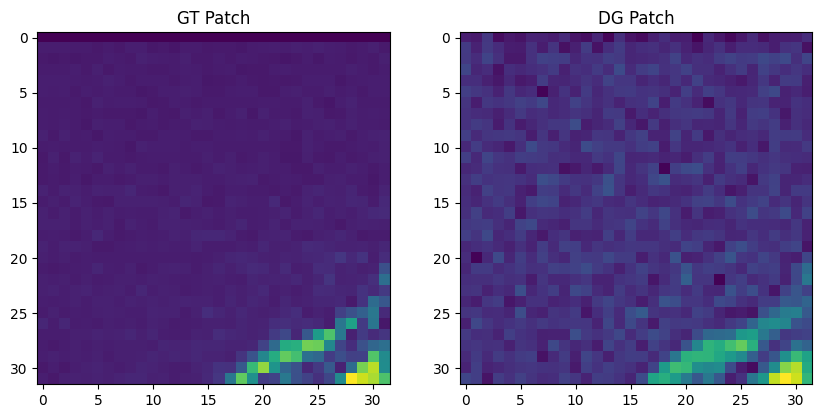

In [7]:
# Visualisiere erstes volumes, erster patch
first_coords = coords[0]  # Koordinaten des ersten Volumes
Volume_Idx, Timestep, X_Start, X_End, Y_Start, Y_End, Z_Start, Z_End = first_coords

volume_gt = gt[Volume_Idx]
volume_dg = degraded[Volume_Idx]

print("Volume GT shape:", volume_gt.shape)
print("Volume DG shape:", volume_dg.shape)

# display volume from with width, heigth, 0 for 2d image and timestep
image_gt = volume_gt[X_Start:X_End, Y_Start:Y_End, 0, Timestep]
image_dg = volume_dg[X_Start:X_End, Y_Start:Y_End, 0, Timestep]


plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(image_gt)
plt.title("GT Patch")

plt.subplot(1,2,2)
plt.imshow(image_dg)
plt.title("DG Patch")

plt.show()

### Dataset

In [8]:
import torch
from torch.utils.data import Dataset, DataLoader

class VolumeDataset(Dataset):
    def __init__(self, degraded_volumes, gt_volumes, coords):
        """
        Args:
            degraded_volumes: Liste/Array der degradierten fMRI-Daten (Input).
            gt_volumes:       Liste/Array der Ground-Truth-Daten (Target).
            coords:           NumPy-Array mit den Koordinaten (Gesamtanzahl_Patches, 8).
        """
        assert len(degraded_volumes) == len(gt_volumes), "Anzahl der degraded und gt Volumes muss gleich sein!"
        
        self.degraded_volumes = degraded_volumes
        self.gt_volumes = gt_volumes
        self.coords = coords

    def __len__(self):
        return len(self.coords)

    def __getitem__(self, idx):
        # 1. Koordinaten für diesen Patch anhand Index auslesen
        coord = self.coords[idx]
        volume_idx, timestep, x_start, x_end, y_start, y_end, z_start, z_end = coord
        
        # Volumes holen
        deg_volume = self.degraded_volumes[volume_idx]
        gt_volume  = self.gt_volumes[volume_idx]

        # Patch erstellen
        patch_deg = deg_volume[x_start:x_end, y_start:y_end, z_start:z_end, timestep]
        patch_gt  = gt_volume[x_start:x_end, y_start:y_end, z_start:z_end, timestep]

        # 3. In PyTorch-Tensoren umwandeln und Channel-Dimension hinzufügen (1, X, Y, Z)
        tensor_deg = torch.tensor(patch_deg, dtype=torch.float32).unsqueeze(0)
        tensor_gt  = torch.tensor(patch_gt, dtype=torch.float32).unsqueeze(0)


        # Normalisierung nicht global über Volume, sondern nur über den Patch
        # Z-Score Normalisierung: (x - mean) / (std + eps)
        mean_deg = tensor_deg.mean()
        std_deg = tensor_deg.std() + 1e-8

        # BEIDE mit denselben Werten normalisieren!
        tensor_deg = (tensor_deg - mean_deg) / std_deg
        tensor_gt  = (tensor_gt - mean_deg) / std_deg  # Wichtig: auch mean_deg/std_deg nutzen!

        # Das Dataset gibt nun ein Tupel zurück: (Input, Target, Coordinates)
        # Koordinaten werden zurückgegeben für spätere Rekonstruktion
        return tensor_deg, tensor_gt, coords[idx]  
    

### Dataset + Dataloader

In [9]:
dataset = VolumeDataset(degraded, gt, coords)
print(f"Gesamtanzahl Patches im Dataset: {len(dataset)}")

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

print(f"Train size: {len(train_dataset)}, Test size: {len(test_dataset)}")

train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)

# Use seperate dataloader to generate predictions. On whole dataset
val_dataloader = DataLoader(dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

# garbage collector
import gc
gc.collect()

Gesamtanzahl Patches im Dataset: 19920
Train size: 15936, Test size: 3984


6299

###  3D CNN

In [10]:
import torch.nn as nn
import torch.nn.functional as F


class ConvBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.bn = nn.BatchNorm3d(channels)
        self.conv = nn.Conv3d(
            channels, channels,
            kernel_size=3,
            padding=1
        )

    def forward(self, x):
        x = self.bn(x)
        x = self.conv(x)
        x = F.relu(x)
        return x


class CNN3D(nn.Module):
    def __init__(self):
        super().__init__()

        # First block: input -> 64 channels
        self.first = nn.Sequential(
            nn.Conv3d(1, 64, kernel_size=3, padding=1),
            nn.ReLU()
        )

        # 7 repeated blocks
        self.blocks = nn.Sequential(
            *[ConvBlock(64) for _ in range(7)]
        )

        # Last block (no activation)
        self.last = nn.Sequential(
            nn.BatchNorm3d(64),
            nn.Conv3d(64, 1, kernel_size=3, padding=1)
        )

    def forward(self, x):
        x = self.first(x)
        x = self.blocks(x)
        x = self.last(x)
        return x

In [11]:
#optimizer
criterion = nn.MSELoss()
model = CNN3D()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

#training setup
num_epochs = 20
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [12]:
#training
if RUN_WITH_TRAINING:
    model = model.to(device)

    print("Starting epochs...")
    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0

        for dg, gt, coord in train_dataloader:
        
            dg = dg.to(device)
            gt = gt.to(device)

            optimizer.zero_grad()

            output = model(dg)

            loss = criterion(output, gt)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}")

Modell speichern und laden - wichtig für NLM

In [13]:
if RUN_WITH_TRAINING:
    torch.save(model.state_dict(), 'model_weights.pth')

In [14]:
if not RUN_WITH_TRAINING:
    model = CNN3D() 

    # 2. Gewichte laden
    model.load_state_dict(torch.load('model_weights.pth'))


In [15]:
# Problem: In 2 Schritten die Prediction Patches zu erstellen, und dann rekonstruieren, braucht viel RAM für alle Patches.
# Deswegen: In einem Schritt machen :(
# Aber: Immerhin schöner und verständlicher Code

def inference_and_reconstruction(model: CNN3D, gt: list, val_dataloader: DataLoader):
    """
    Führt GPU-Inferenz für Patches durch. Rekonstruiert die Patches zurück in ihre ursprüngliche Volume 4D-Struktur.
    Die Funktion erstellt leere Ziel-Volumes auf der CPU und setzt die vom Modell generierten Vorhersagen anhand der 
    mitgelieferten Koordinaten direkt an den korrekten räumlichen und zeitlichen Positionen wieder zusammen.

    Args:
        model (torch.nn.Module): Das trainierte PyTorch-Modell für die Inferenz.
        gt (list of torch.Tensor oder np.ndarray): Die Originalliste der Ground-Truth-
            Volumina. Wird nur genutzt, um Ziel Shape von Predictions zu bestimmen 

    Returns:
        list of torch.Tensor: Eine Liste von rekonstruierten 4D-Vorhersage-Volumina, 
            deren Indizes und Shapes exakt der Struktur der 'gt'-Liste entsprechen.
    """
    model = model.to(device)
    model.eval()

    # Erstelle leere Ziel-Volumes basierend auf der Struktur deiner 'gt'-Liste
    predictions = []

    for volume in gt:
        vol_shape = volume.shape  # (X, Y, Z, Timesteps)
        predictions.append(torch.zeros(vol_shape, dtype=torch.float32))


    print(f"prediction_volumes len: {len(predictions)}")
    print(f"prediction_volumes shapes: {[vol.shape for vol in predictions]}")


    print("Starte Inferenz und rekonstruiere Patches...")

    with torch.no_grad():
        for dg_batch, _, coord_batch in val_dataloader:
            
            # mache gpu inferenz und schiebe wieder auf cpu/ram
            dg_batch = dg_batch.to(device)
            prediction_batch = model(dg_batch)
            prediction_batch = prediction_batch.cpu()
            
            current_batch_size = prediction_batch.shape[0]

            # für alle 32 prediction patches im batch:
            for i in range(current_batch_size):
                # hole die i-ten coordinaten
                c = coord_batch[i].numpy().astype(int)
                
                volume_idx, timestep, x_start, x_end, y_start, y_end, z_start, z_end = c

                # Squeeze entfernt die Channel-Dimension [1, 32, 32, 31] -> [32, 32, 31]
                patch_pred = prediction_batch[i].squeeze(0)
                    
                # setze den patch in das Volume ein
                predictions[volume_idx][x_start:x_end, y_start:y_end, z_start:z_end, timestep] = patch_pred

    return predictions



predictions = inference_and_reconstruction(model, gt, val_dataloader)
print("Prediction Volumes shape:")
print([vol.shape for vol in predictions])

prediction_volumes len: 2
prediction_volumes shapes: [torch.Size([128, 128, 93, 219]), torch.Size([128, 128, 93, 196])]
Starte Inferenz und rekonstruiere Patches...
Prediction Volumes shape:
[torch.Size([128, 128, 93, 219]), torch.Size([128, 128, 93, 196])]


Volume Pred shape: torch.Size([128, 128, 93, 219])


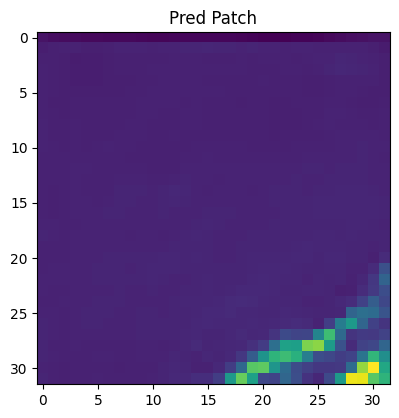

In [16]:
# Einzelne Testvisualisierung !!
# Richtige Visualisierungen alle nebeneinander & Difference Maps müssen wir weiter unten noch machen !

# Hole erstes Bild und Visualisiere
first_coords = coords[0]
Volume_Idx, Timestep, X_Start, X_End, Y_Start, Y_End, Z_Start, Z_End = first_coords

volume_pred = predictions[Volume_Idx]

print("Volume Pred shape:", volume_pred.shape)

image_pred = volume_pred[X_Start:X_End, Y_Start:Y_End, 0, Timestep]

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(image_pred)
plt.title("Pred Patch")
plt.show()

### Non-Local-Means filter (NLM)

In [ ]:
from skimage.restoration import denoise_nl_means, estimate_sigma

# Entsprechend die Prediction Volumes aus der Liste predictions nutzen.
# Die nächsten 3 Zellen laufen überraschender Weise alle auch durch, aber sind ja eigentlich veraltet !?


def nlm_3d(cnn_output, h=0.8, patch_size=5, patch_distance=6):
    """
    cnn_output: (1, X, Y, Z) or (X, Y, Z)
    returns refined volume
    """

    if cnn_output.ndim == 4:
        cnn_output = cnn_output[0]

    X, Y, Z = cnn_output.shape
    result = np.zeros_like(cnn_output)

    for z in range(Z):
        slice_img = cnn_output[:, :, z]

        sigma_est = np.mean(estimate_sigma(slice_img, channel_axis=None))

        nlm = denoise_nl_means(
            slice_img,
            h=h * sigma_est,
            fast_mode=True,
            patch_size=patch_size,
            patch_distance=patch_distance,
            channel_axis=None
        )

        result[:, :, z] = nlm

    return result

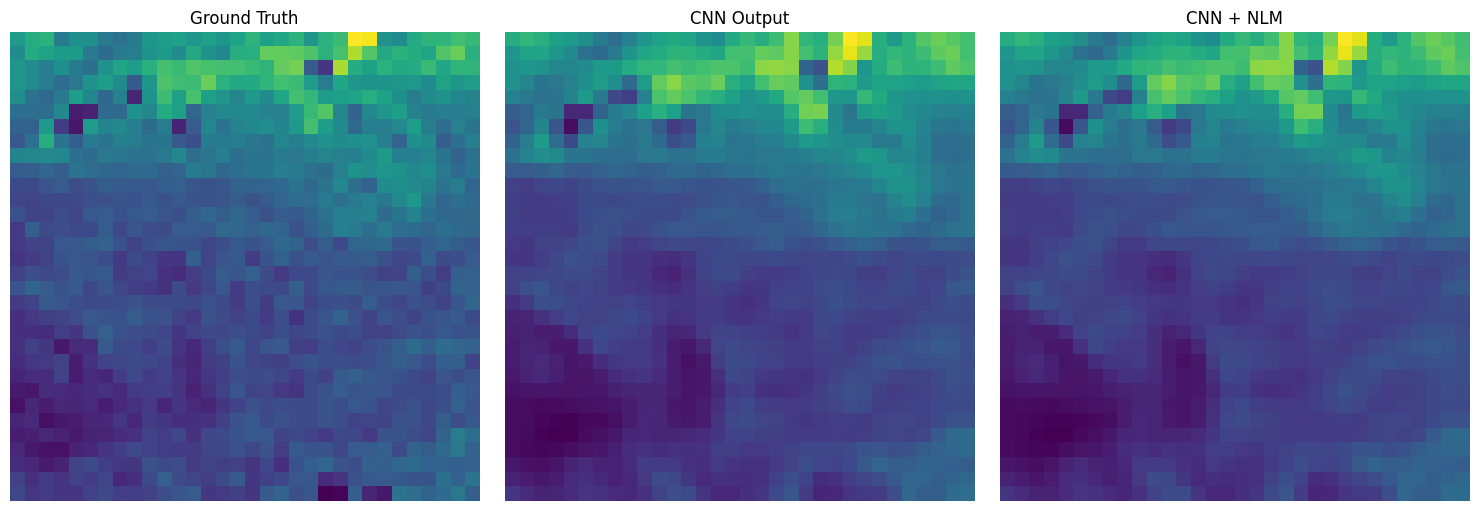

In [18]:
# CNN + NLM Denoising
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

model.eval()

dg_batch0, gt_batch0, coords_of_patch = next(iter(train_dataloader))

with torch.no_grad():

    # Eingabe auf Device verschieben
    dg_batch0 = dg_batch0.to(device)

    # CNN Vorhersage
    cnn_out = model(dg_batch0)

    # Tensor -> NumPy
    cnn_out_np = cnn_out.detach().cpu().numpy()

    # NLM auf jede Prediction anwenden
    refined_outputs = []

    for i in range(cnn_out_np.shape[0]):

        refined = nlm_3d(
            cnn_out_np[i],
            h=0.8,
            patch_size=5,
            patch_distance=6
        )

        refined_outputs.append(refined)

    refined_outputs = np.array(refined_outputs)

# Beispielslice anzeigen
gt_slice = gt_batch0[0, 0, :, :, 0].cpu().numpy()

cnn_slice = cnn_out_np[0, 0, :, :, 0]

nlm_slice = refined_outputs[0, :, :, 0]

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(gt_slice)
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(cnn_slice)
plt.title("CNN Output")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(nlm_slice)
plt.title("CNN + NLM")
plt.axis("off")

plt.tight_layout()
plt.show()

### Visualisierungen

siehe data prep: noise-only differences, resolution-only differences (difference map)

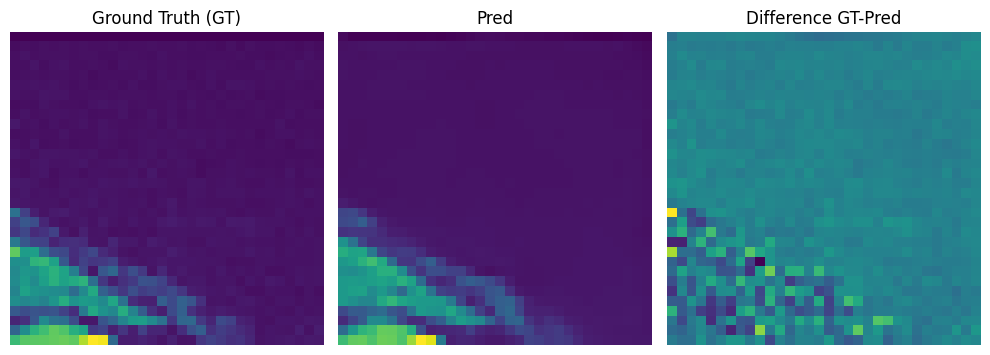

In [19]:
# GT vs. Prediction + Difference Map (Prediction, GT)
# noise only
dg_batch0, gt_batch0, coords_of_patch = next(iter(train_dataloader))
dg_batch0 = dg_batch0.to(device)

gt_batch0 = gt_batch0[0, 0, :, :, 0]
plt.figure(figsize=(10, 5))
plt.subplot(1, 3, 1)
plt.imshow(gt_batch0)
plt.title("Ground Truth (GT)")
plt.axis('off')

pred_dg = model(dg_batch0).detach().cpu()

pred_dg = pred_dg[0, 0, :, :, 0]
plt.subplot(1, 3, 2)
plt.imshow(pred_dg)
plt.title("Pred")
plt.axis('off')


difference_map = gt_batch0 - pred_dg
plt.subplot(1, 3, 3)
plt.imshow(difference_map)
plt.title("Difference GT-Pred")
plt.axis('off')


plt.tight_layout()
plt.show()
 # Visualisierung sieht schlecht aus, Modell ist ja auch noch nicht trainiert zum jetzigen Stand
 # Dataloader enthält Shuffle=True, deswegen immer zufälliger neuer 1. Batch

# SNR Berechnung auf Prediction und Ground Truth

In [20]:
from skimage.metrics import peak_signal_noise_ratio


gt_batch0 = gt_batch0.numpy()
pred_dg = pred_dg.numpy()

dg_batch0 = dg_batch0[0, 0, :, :, 0].numpy()

psnr_gt_dg = peak_signal_noise_ratio(gt_batch0, dg_batch0, data_range=gt_batch0.max() - gt_batch0.min())
print(f"PSNR of {psnr_gt_dg}")

psnr_gt_pred = peak_signal_noise_ratio(gt_batch0, pred_dg, data_range=gt_batch0.max() - gt_batch0.min())
print(f"PSNR of {psnr_gt_pred}")

TypeError: can't convert cuda:0 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.

## Rekonstruktion 3D Bilder

In [ ]:
# Allgemeine Rekonstruktion überarbeiten => Funktion
# Predictions erstellen (vorher) und nur Predictions rekonstruieren
# Non Local Means auf Rekonstruierte Preds anwenden

In [ ]:
# def rebuild_3d(patches, original_shape, patch_size=28, stride=28):
#     """
#     patches: Die extrahierten Patches für EINEN Zeitschritt (N, 12, 12, 12)
#     original_shape: Die Form des ursprünglichen 3D-Bildes (X, Y, Z)
#     """
#     x, y, z = original_shape
#     # Leeres Volumen mit Nullen erstellen
#     reconstructed = np.zeros((x, y, z), dtype=patches.dtype)
    
#     patch_idx = 0
    
#     # Die gleichen Schleifen wie beim Splitten durchlaufen
#     for i in range(0, x - patch_size + 1, stride):
#         for j in range(0, y - patch_size + 1, stride):
#             for k in range(0, z - patch_size + 1, stride):
                
#                 # Den aktuellen Patch an die richtige Stelle setzen
#                 reconstructed[i:i+patch_size, 
#                               j:j+patch_size, 
#                               k:k+patch_size] = patches[patch_idx]
                
#                 patch_idx += 1
                
#     return reconstructed

def rebuild_3d(patches, target_shape):
    x, y, z = target_shape
    reconstructed = np.zeros((x, y, z))
    
    # Dynamisch die Patch-Größe aus dem ersten Patch bestimmen (hier 64)
    patch_size = patches.shape[1] 
    
    # Wenn du beim Splitten keinen Überlapp verwendet hast, ist der Stride gleich der Patch-Größe
    stride = patch_size 
    
    patch_idx = 0
    for i in range(0, x - patch_size + 1, stride):
        for j in range(0, y - patch_size + 1, stride):
            for k in range(0, z - patch_size + 1, stride):
                
                # Sicherstellen, dass wir nicht über das Array-Ende hinauslesen
                if patch_idx < len(patches):
                    reconstructed[i:i+patch_size, 
                                  j:j+patch_size, 
                                  k:k+patch_size] = patches[patch_idx]
                    patch_idx += 1
                    
    return reconstructed

Für Ground Truth:

Für Degraded:

In [ ]:
# garbage collector
import gc
gc.collect()

# 1. Bestimme, wie viele Patches ein einzelnes 3D-Volumen hat
# (Das ist all_chunks_gt.shape[1] aus deinem vorherigen Code)
patches_per_timestep = all_chunks_dg.shape[1]
print(patches_per_timestep)

num_timesteps = all_chunks_dg.shape[0]

print(num_timesteps)

original_3d_shape = (128, 128, 84)

print(original_3d_shape)


# Angenommen 'denoised_data' sind deine bearbeiteten Patches in Shape (Gesamt, 1, 12, 12, 12)
# Wir entfernen zuerst die Kanal-Dimension
denoised_data = data_gt.squeeze(1) 
print(denoised_data.shape)
reconstructed_volume_4d = []

for t in range(num_timesteps):
    # Extrahiere die Patches für diesen spezifischen Zeitschritt
    start = t * patches_per_timestep
    end = start + patches_per_timestep
    current_time_patches = denoised_data[start:end]
    
    # Rekonstruiere das 3D-Bild
    img_3d = rebuild_3d(current_time_patches, original_3d_shape)
    reconstructed_volume_4d.append(img_3d)

# Wieder zu 4D zusammenfügen (X, Y, Z, Time)
final_volume_dg = np.stack(reconstructed_volume_4d, axis=-1)

print(final_volume_dg.shape) # Sollte wieder der Ursprungsform entsprechen


Für Prediction (CNN):

In [ ]:
# #Zunächst Patches erzeugen:
# # garbage collector
# import gc
# gc.collect()


# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# model.eval()
# model.to(device)

# predicted_patches = []

# with torch.no_grad():

#     for i in range(len(data_dg)):

#         # numpy -> tensor
#         patch = torch.tensor(
#             data_dg[i],
#             dtype=torch.float32
#         )

#         # Nur Batch-Dimension hinzufügen
#         # Shape:
#         # (1, 1, 28, 28, 28)

#         patch = patch.unsqueeze(0).to(device)

#         # prediction
#         pred = model(patch)

#         # zurück zu numpy
#         pred_np = pred.squeeze().cpu().numpy()

#         predicted_patches.append(pred_np)

# predicted_patches = np.array(predicted_patches)

# print("CNN predicted patches shape:")
# print(predicted_patches.shape)

# Beschleunigte Vorhersage mit Mini-Batches
from torch.utils.data import TensorDataset, DataLoader

# Konvertiere das gesamte numpy-Array auf einmal in einen Tensor
# (Kanal-Dimension beibehalten, falls das Modell sie erwartet, z.B. Shape: N, 1, 64, 64, 64)
dataset = TensorDataset(torch.tensor(data_dg, dtype=torch.float32))
dataloader = DataLoader(dataset, batch_size=32, shuffle=False) # Batch-Size an VRAM anpassen

model.eval()
model.to(device)

predicted_list = []

with torch.no_grad():
    for batch in dataloader:
        inputs = batch[0].to(device)
        preds = model(inputs)
        
        # Zurück zu Numpy und in Liste speichern
        predicted_list.append(preds.cpu().numpy())

# Alle Batches wieder zusammenfügen
predicted_patches = np.concatenate(predicted_list, axis=0)
# Falls nötig, die Batch-/Kanal-Dimensionen analog zu vorher anpassen (squeeze)
predicted_patches = predicted_patches.squeeze(1) 

print("CNN predicted patches shape:", predicted_patches.shape)


In [ ]:
# Rekonstruktion der CNN Predictions

# Anzahl Patches pro Zeitschritt
patches_per_timestep = all_chunks_dg.shape[1]

print("patches_per_timestep:", patches_per_timestep)

# Anzahl Timesteps
num_timesteps = all_chunks_dg.shape[0]

print("num_timesteps:", num_timesteps)

# Ursprüngliche 3D Form
original_3d_shape = (128, 128, 84)

print("original_3d_shape:", original_3d_shape)

reconstructed_volume_4d = []

for t in range(num_timesteps):

    # Richtige Patches dieses Timesteps holen
    start = t * patches_per_timestep
    end = start + patches_per_timestep

    current_time_patches = predicted_patches[start:end]

    # 3D rekonstruieren
    img_3d = rebuild_3d(
        current_time_patches,
        original_3d_shape
    )

    reconstructed_volume_4d.append(img_3d)

# Wieder 4D erzeugen
final_volume_pr = np.stack(reconstructed_volume_4d, axis=-1)

print("final_volume_pr shape:")
print(final_volume_pr.shape)

Für CNN+NLM:

In [ ]:
# NLM auf CNN Predictions anwenden

nlm_patches = []

for i in range(len(predicted_patches)):

    patch = predicted_patches[i]

    refined = nlm_3d(
        patch,
        h=0.8,
        patch_size=5,
        patch_distance=6
    )

    nlm_patches.append(refined)

nlm_patches = np.array(nlm_patches)

print("NLM patches shape:")
print(nlm_patches.shape)



In [ ]:
# Rekonstruktion der NLM Patches

# Anzahl Patches pro Zeitschritt
patches_per_timestep = all_chunks_dg.shape[1]

print("patches_per_timestep:", patches_per_timestep)

# Anzahl Timesteps
num_timesteps = all_chunks_dg.shape[0]

print("num_timesteps:", num_timesteps)

# Ursprüngliche 3D Form
original_3d_shape = (128, 128, 84)

print("original_3d_shape:", original_3d_shape)

reconstructed_volume_4d = []

for t in range(num_timesteps):

    # Richtige Patches dieses Timesteps holen
    start = t * patches_per_timestep
    end = start + patches_per_timestep

    current_time_patches = nlm_patches[start:end]

    # 3D rekonstruieren
    img_3d = rebuild_3d(
        current_time_patches,
        original_3d_shape
    )

    reconstructed_volume_4d.append(img_3d)

# Wieder 4D erzeugen
final_volume_nlm = np.stack(reconstructed_volume_4d, axis=-1)

print("final_volume_nlm shape:")
print(final_volume_nlm.shape)

In [ ]:
# garbage collector
import gc
gc.collect()

# Rekonstruktion der GT Patches

# 1. Bestimme, wie viele Patches ein einzelnes 3D-Volumen hat
# (Das ist all_chunks_gt.shape[1] aus deinem vorherigen Code)
patches_per_timestep = all_chunks_gt.shape[1]
print(patches_per_timestep)

num_timesteps = all_chunks_gt.shape[0]

print(num_timesteps)

original_3d_shape = (128, 128, 84)

print(original_3d_shape)


# Angenommen 'denoised_data' sind deine bearbeiteten Patches in Shape (Gesamt, 1, 12, 12, 12)
# Wir entfernen zuerst die Kanal-Dimension
denoised_data = data_gt.squeeze(1) 
print(denoised_data.shape)
reconstructed_volume_4d = []

for t in range(num_timesteps):
    # Extrahiere die Patches für diesen spezifischen Zeitschritt
    start = t * patches_per_timestep
    end = start + patches_per_timestep
    current_time_patches = denoised_data[start:end]
    
    # Rekonstruiere das 3D-Bild
    img_3d = rebuild_3d(current_time_patches, original_3d_shape)
    reconstructed_volume_4d.append(img_3d)

# Wieder zu 4D zusammenfügen (X, Y, Z, Time)
final_volume_gt = np.stack(reconstructed_volume_4d, axis=-1)

print(final_volume_gt.shape) # Sollte wieder der Ursprungsform entsprechen



In [ ]:
visualization_gt = final_volume_gt[:, :, 0, 0]
# visualization_dg = dg[:, :, 0, 0]
visualization_pr = final_volume_pr[:, :, 0, 0]
# visualization_nlm = final_volume_nlm[:, :, 0, 0]

plt.figure(figsize=(16, 10))

plt.subplot(2, 3, 1)
plt.imshow(np.rot90(visualization_gt), cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

# plt.subplot(2, 3, 2)
# plt.imshow(np.rot90(visualization_dg), cmap="gray")
# plt.title("degraded")
# plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(np.rot90(visualization_pr), cmap="gray")
plt.title("prediction")
plt.axis("off")

# plt.subplot(2, 3, 3)
# plt.imshow(np.rot90(visualization_nlm), cmap="gray")
# plt.title("cnn + nlm")
# plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(np.rot90(visualization_gt - visualization_pr), cmap='bwr')
plt.title("Difference map GT - PR")
plt.axis("off")
plt.colorbar(fraction=0.046, pad=0.04)

# plt.subplot(2, 3, 5)
# plt.imshow(np.rot90(visualization_gt - visualization_nlm), cmap='bwr')
# plt.title("Difference map GT - NLM")
# plt.axis("off")
# plt.colorbar(fraction=0.046, pad=0.04)

# plt.subplot(2, 3, 4)
# plt.imshow(np.rot90(show_kspace(gt_slice), 1), cmap="gray")
# plt.title("Ground Truth k-space")
# plt.axis("off")

# plt.subplot(2, 3, 5)
# plt.imshow(np.rot90(show_kspace(lowres_slice), 1), cmap="gray")
# plt.title("Low-res k-space")
# plt.axis("off")

# plt.subplot(2, 3, 6)
# plt.imshow(np.rot90(show_kspace(gt_slice) - show_kspace(lowres_slice), 1), cmap="gray")
# plt.title("Difference k-space")
# plt.axis("off")
# plt.colorbar(fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()
